# M5 Exogenous Effects with Per-Series Importance

This notebook follows the same workflow as the other notebook, but on real M5 data.

Goal:
- Aggregate daily demand to state x category series (9 total)
- Train one global multi-series forecasting model
- Use xeries conditional permutation importance globally and per series
- Compare SNAP and holiday effects across states and product categories

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from skforecast.recursive import ForecasterRecursiveMultiSeries
from skforecast.model_selection import bayesian_search_forecaster_multiseries, TimeSeriesFold

from xeries import (
    ConditionalPermutationImportance,
    SkforecastAdapter,
    plot_importance_bar,
    plot_importance_per_series,
)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

print('Imports loaded.')

Imports loaded.


## 1. Load M5 and Aggregate to State x Category

In [2]:
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
raw_dir = project_root / 'data' / 'raw' / 'm5-forecasting-accuracy'

calendar_path = raw_dir / 'calendar.csv'
sales_path = raw_dir / 'sales_train_validation.csv'

if not calendar_path.exists() or not sales_path.exists():
    raise FileNotFoundError(f'Missing input files in {raw_dir}')

calendar_df = pd.read_csv(calendar_path, parse_dates=['date'])
calendar_df['holiday_flag'] = (
    calendar_df['event_name_1'].fillna('').ne('')
    | calendar_df['event_name_2'].fillna('').ne('')
).astype(int)

header_cols = pd.read_csv(sales_path, nrows=0).columns.tolist()
d_cols = [c for c in header_cols if c.startswith('d_')]
if not d_cols:
    raise ValueError('No d_* columns found in sales file.')


def ensure_state_cat(df: pd.DataFrame) -> pd.DataFrame:
    if {'state_id', 'cat_id'}.issubset(df.columns):
        return df
    id_col = next((c for c in ['id', 'series_id'] if c in df.columns), None)
    if id_col is None:
        raise ValueError('Cannot derive state/category fields.')

    parts = df[id_col].astype(str).str.replace('_validation', '', regex=False).str.split('_', expand=True)
    if parts.shape[1] < 4:
        raise ValueError('Unable to parse id into expected fields.')

    df = df.copy()
    df['cat_id'] = parts[0]
    df['state_id'] = parts[3]
    return df


chunks = []
for chunk in pd.read_csv(sales_path, chunksize=1500):
    chunk = ensure_state_cat(chunk)
    grouped = chunk.groupby(['state_id', 'cat_id'], as_index=True)[d_cols].sum()
    chunks.append(grouped)

agg_wide = pd.concat(chunks).groupby(level=[0, 1]).sum().sort_index()

print(f'Aggregated matrix shape: {agg_wide.shape}')
print('Series combinations:')
print(agg_wide.index.to_frame(index=False).to_string(index=False))

Aggregated matrix shape: (9, 1913)
Series combinations:
state_id    cat_id
      CA     FOODS
      CA   HOBBIES
      CA HOUSEHOLD
      TX     FOODS
      TX   HOBBIES
      TX HOUSEHOLD
      WI     FOODS
      WI   HOBBIES
      WI HOUSEHOLD


In [3]:
# Output directories
OUTPUT_ROOT = project_root / 'outputs'
FIGURE_DIR = OUTPUT_ROOT / 'figures'
TUNING_DIR = OUTPUT_ROOT / 'tuning'
TABLE_DIR = OUTPUT_ROOT / 'tables'
METADATA_DIR = OUTPUT_ROOT / 'metadata'

for d in [FIGURE_DIR, TUNING_DIR, TABLE_DIR, METADATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Output directories created under {OUTPUT_ROOT}')

Output directories created under E:\research\beyond-global-averages\outputs


## 2. Build Daily Panel with SNAP and Holiday Features

In [4]:
panel = (
    agg_wide.reset_index()
    .melt(id_vars=['state_id', 'cat_id'], var_name='d', value_name='sales')
)

calendar_features = calendar_df[['d', 'date', 'holiday_flag', 'snap_CA', 'snap_TX', 'snap_WI']]
panel = panel.merge(calendar_features, on='d', how='left')

snap_col_by_state = {'CA': 'snap_CA', 'TX': 'snap_TX', 'WI': 'snap_WI'}
panel['snap_flag'] = 0
for state, snap_col in snap_col_by_state.items():
    mask = panel['state_id'].eq(state)
    panel.loc[mask, 'snap_flag'] = panel.loc[mask, snap_col].astype(int)

panel = panel.sort_values(['state_id', 'cat_id', 'date']).reset_index(drop=True)

print(f'Panel rows: {len(panel):,}')
print(f'Date range: {panel["date"].min().date()} -> {panel["date"].max().date()}')
display(panel[['date', 'state_id', 'cat_id', 'sales', 'snap_flag', 'holiday_flag']].head(10))

C:\Users\Matty\AppData\Local\Temp\ipykernel_40228\709328077.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_wide.reset_index()


Panel rows: 17,217
Date range: 2011-01-29 -> 2016-04-24


,date,state_id,cat_id,sales,snap_flag,holiday_flag
0,2011-01-29,CA,FOODS,10101,0,0
1,2011-01-30,CA,FOODS,9862,0,0
2,2011-01-31,CA,FOODS,6944,0,0
3,2011-02-01,CA,FOODS,7864,1,0
4,2011-02-02,CA,FOODS,7178,1,0
5,2011-02-03,CA,FOODS,8256,1,0
6,2011-02-04,CA,FOODS,9005,1,0
7,2011-02-05,CA,FOODS,11870,1,0
8,2011-02-06,CA,FOODS,10977,1,1
9,2011-02-07,CA,FOODS,8637,1,0


## 3. Prepare Multi-Series Inputs for skforecast

In [5]:
exog_features = ['snap_flag', 'holiday_flag']

series_dict = {}
exog_dict = {}
series_ids = []

for (state_id, cat_id), grp in panel.groupby(['state_id', 'cat_id'], sort=True):
    series_name = f'{state_id}_{cat_id}'
    series_ids.append(series_name)

    subset = grp.sort_values('date').set_index('date').asfreq('D')
    # Use raw sales; forecaster's transformer_series handles scaling internally.
    series_dict[series_name] = subset['sales'].rename(series_name)
    exog_dict[series_name] = subset[exog_features]

print(f'Created {len(series_dict)} series (raw sales, internal scaling via transformer_series).')
print(series_ids)
print('Example target values (first series):')
print(series_dict[series_ids[0]].head())
display(exog_dict[series_ids[0]].head())

Created 9 series (raw sales, internal scaling via transformer_series).
['CA_FOODS', 'CA_HOBBIES', 'CA_HOUSEHOLD', 'TX_FOODS', 'TX_HOBBIES', 'TX_HOUSEHOLD', 'WI_FOODS', 'WI_HOBBIES', 'WI_HOUSEHOLD']
Example target values (first series):
date
2011-01-29    10101
2011-01-30     9862
2011-01-31     6944
2011-02-01     7864
2011-02-02     7178
Freq: D, Name: CA_FOODS, dtype: int64


,snap_flag,holiday_flag
date,,
2011-01-29,0,0
2011-01-30,0,0
2011-01-31,0,0
2011-02-01,1,0
2011-02-02,1,0


## 4. Optuna Hyperparameter Tuning

Use Bayesian search to tune lag structure and LightGBM hyperparameters. Save tuning artifacts for reproducibility.

In [6]:
# Tuning configuration (publication profile)
RANDOM_SEED = 42
N_TRIALS = 20  # Use 200+ for camera-ready reruns

# Define search space (includes lags)
lags_grid = [7, 14, 21, 28, [1,7, 14, 21, 28],[1,2, 7, 14,21,28]]

def search_space(trial):
    return {
        'lags': trial.suggest_categorical('lags', lags_grid),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

# Base forecaster for search
forecaster_search = ForecasterRecursiveMultiSeries(
    regressor=LGBMRegressor(random_state=RANDOM_SEED, verbose=-1),
    lags=7,
    encoding='ordinal',
    transformer_series=StandardScaler(),
)

# Time-based validation split (last 28 days for validation)
end_date = panel['date'].max()
val_start = end_date - pd.Timedelta(days=27)

# Cross-validation fold configuration
cv = TimeSeriesFold(
    initial_train_size=len(series_dict[series_ids[0]]) - 28,
    steps=28,
    fixed_train_size=False,
    refit=True,
)

print(f'Running Bayesian search with {N_TRIALS} trials...')
print(f'Validation period: {val_start.date()} to {end_date.date()}')

search_results = bayesian_search_forecaster_multiseries(
    forecaster=forecaster_search,
    series=series_dict,
    exog=exog_dict,
    search_space=search_space,
    cv=cv,
    metric='mean_squared_error',
    n_trials=N_TRIALS,
    random_state=RANDOM_SEED,
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True,
)

# Extract best configuration (new API returns (results_df, best_trial))
trials_df, best_trial = search_results
best_lags = trials_df.loc[0, 'lags']
best_params = trials_df.loc[0, 'params']

print(f'\nBest lags: {best_lags}')
print(f'Best params: {best_params}')

# Save tuning artifacts
trials_df.to_csv(TUNING_DIR / '02_m5_optuna_trials.csv', index=False)
print(f'Saved trials to {TUNING_DIR / "02_m5_optuna_trials.csv"}')

best_config = {
    'best_lags': best_lags.tolist() if hasattr(best_lags, 'tolist') else (best_lags if isinstance(best_lags, list) else list(range(1, best_lags + 1))),
    'best_params': best_params,
    'n_trials': N_TRIALS,
    'random_seed': RANDOM_SEED,
    'metric': 'mean_squared_error',
}
with open(METADATA_DIR / '02_m5_best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print(f'Saved best config to {METADATA_DIR / "02_m5_best_config.json"}')

# Create LaTeX table for best parameters
params_for_latex = {
    'Parameter': [],
    'Value': [],
}
params_for_latex['Parameter'].append('Lags')
params_for_latex['Value'].append(str(best_config['best_lags']))
for k, v in best_params.items():
    params_for_latex['Parameter'].append(k.replace('_', '\\_'))
    params_for_latex['Value'].append(str(v))
params_for_latex['Parameter'].extend(['N Trials', 'Random Seed', 'Metric'])
params_for_latex['Value'].extend([str(N_TRIALS), str(RANDOM_SEED), 'MSE'])

params_df = pd.DataFrame(params_for_latex)
latex_params = params_df.to_latex(index=False, escape=False, column_format='ll',
    caption='M5 optimal hyperparameters from Bayesian search.',
    label='tab:02_m5_best_params')
with open(TABLE_DIR / '02_m5_best_params.tex', 'w') as f:
    f.write(latex_params)
print(f'Saved LaTeX params table to {TABLE_DIR / "02_m5_best_params.tex"}')

Running Bayesian search with 20 trials...
Validation period: 2016-03-28 to 2016-04-24


C:\Users\Matty\AppData\Local\Temp\ipykernel_40228\111940755.py:21: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster_search = ForecasterRecursiveMultiSeries(


  0%|          | 0/20 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  7 14 21 28] 
  Parameters: {'n_estimators': 441, 'learning_rate': 0.055874573945977626, 'num_leaves': 40, 'max_depth': 4, 'min_child_samples': 16, 'reg_alpha': 0.00051611156757311, 'reg_lambda': 0.017353279091115007}
  Backtesting metric: 192748.93021827366
  Levels: ['CA_FOODS', 'CA_HOBBIES', 'CA_HOUSEHOLD', 'TX_FOODS', 'TX_HOBBIES', 'TX_HOUSEHOLD', 'WI_FOODS', 'WI_HOBBIES', 'WI_HOUSEHOLD']


Best lags: [ 1  2  7 14 21 28]
Best params: {'n_estimators': 441, 'learning_rate': 0.055874573945977626, 'num_leaves': 40, 'max_depth': 4, 'min_child_samples': 16, 'reg_alpha': 0.00051611156757311, 'reg_lambda': 0.017353279091115007}
Saved trials to E:\research\beyond-global-averages\outputs\tuning\02_m5_optuna_trials.csv
Saved best config to E:\research\beyond-global-averages\outputs\metadata\02_m5_best_config.json
Saved LaTeX params table to E:\research\beyond-global-averages\outputs\tables\

## 5. Refit Final Model with Best Parameters

Refit the forecaster using the optimal lags and hyperparameters from Optuna search.

In [7]:
# Use best parameters from Optuna search
estimator = LGBMRegressor(
    **best_params,
    random_state=RANDOM_SEED,
    verbose=-1,
)

forecaster = ForecasterRecursiveMultiSeries(
    regressor=estimator,
    lags=best_lags,
    encoding='ordinal',
    transformer_series=StandardScaler(),
)

print(f'Refitting forecaster with best_lags={best_lags}...')
forecaster.fit(series=series_dict, exog=exog_dict)
print('Forecaster fitted with optimized configuration.')

X_train_sk, y_train_sk = forecaster.create_train_X_y(series=series_dict, exog=exog_dict)
series_col = next((c for c in X_train_sk.columns if 'level' in c.lower() or 'series' in c.lower()), None)
if series_col is None:
    raise ValueError('Could not detect series column in X_train_sk.')

explain_features = [c for c in X_train_sk.columns if c != series_col]

print(f'X shape: {X_train_sk.shape}')
print(f'Y shape: {getattr(y_train_sk, "shape", len(y_train_sk))}')
print(f'series_col: {series_col}')

Refitting forecaster with best_lags=[ 1  2  7 14 21 28]...


C:\Users\Matty\AppData\Local\Temp\ipykernel_40228\718121951.py:8: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster = ForecasterRecursiveMultiSeries(


Forecaster fitted with optimized configuration.
X shape: (16965, 9)
Y shape: (16965,)
series_col: _level_skforecast


## 6. Global Feature Importance (xeries)

Computing global importance...


e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== Global importance (top 12) ===


,feature,importance,std
0,lag_1,0.075803,0.001093
6,snap_flag,0.062979,0.001097
2,lag_7,0.053912,0.000996
5,lag_28,0.053149,0.001171
3,lag_14,0.029081,0.000726
7,holiday_flag,0.024140,0.000943
1,lag_2,0.023449,0.000838
4,lag_21,0.020284,0.000606


=== Global exogenous importance ===


,feature,importance,std
6,snap_flag,0.062979,0.001097
7,holiday_flag,0.024140,0.000943


Saved global importance figures to E:\research\beyond-global-averages\outputs\figures


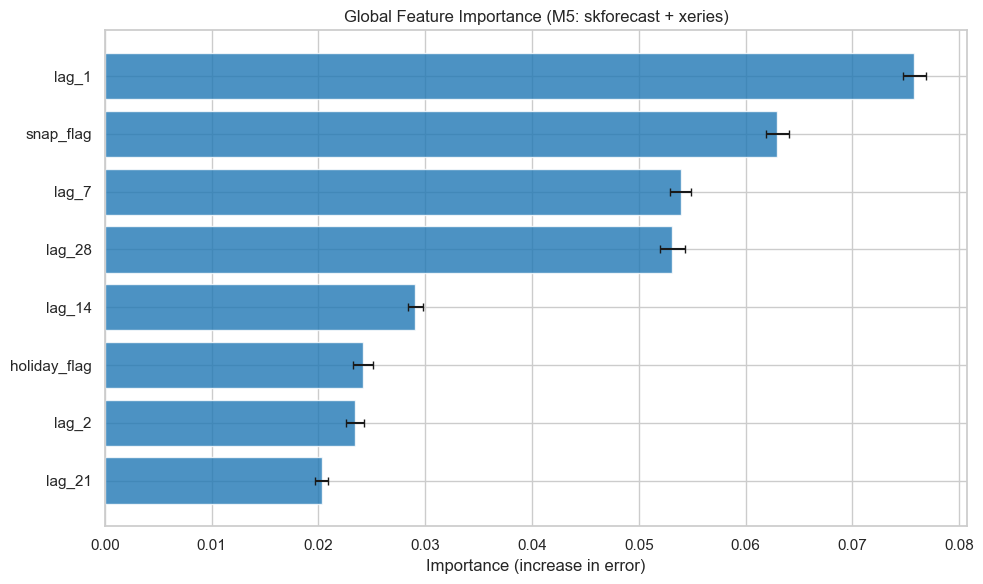

Saved importance tables to E:\research\beyond-global-averages\outputs\tables


In [8]:
adapter = SkforecastAdapter(
    forecaster=forecaster,
    series=series_dict,
    exog=exog_dict,
)

explainer = ConditionalPermutationImportance(
    model=adapter,
    metric=mean_squared_error,
    n_repeats=20,  # Publication level (increased from 5)
    random_state=42,
)

print('Computing global importance...')
global_result = explainer.explain(
    X=X_train_sk,
    y=y_train_sk,
    features=explain_features,
)

importance_df = global_result.to_dataframe().sort_values('importance', ascending=False)
exog_importance_df = importance_df[importance_df['feature'].isin(exog_features)].copy()

print('=== Global importance (top 12) ===')
display(importance_df.head(12))
print('=== Global exogenous importance ===')
display(exog_importance_df)

fig, ax = plot_importance_bar(
    global_result,
    max_features=12,
    title=None,
)
plt.tight_layout()
fig.savefig(FIGURE_DIR / '02_m5_global_importance.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '02_m5_global_importance.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved global importance figures to {FIGURE_DIR}')
plt.show()

# Export CSV tables
importance_df.to_csv(TABLE_DIR / '02_m5_global_importance.csv', index=False)
exog_importance_df.to_csv(TABLE_DIR / '02_m5_global_exog_importance.csv', index=False)

# Export LaTeX tables
latex_importance = importance_df.to_latex(index=False, float_format='%.4f',
    caption='M5 global feature importance scores (all features).',
    label='tab:02_m5_global_importance')
with open(TABLE_DIR / '02_m5_global_importance.tex', 'w') as f:
    f.write(latex_importance)

latex_exog_importance = exog_importance_df.to_latex(index=False, float_format='%.4f',
    caption='M5 global feature importance scores (exogenous features only).',
    label='tab:02_m5_global_exog_importance')
with open(TABLE_DIR / '02_m5_global_exog_importance.tex', 'w') as f:
    f.write(latex_exog_importance)
print(f'Saved importance tables to {TABLE_DIR}')

Computing sklearn permutation importance...


e:\research\beyond-global-averages\.venv\Lib\site-packages\skforecast\base\_forecaster_base.py:357: FutureWarning: The `regressor` attribute is deprecated and will be removed in future versions. Use `estimator` instead.
  warnings.warn(


=== xeries vs sklearn permutation importance (top 12 by xeries) ===


,feature,importance,std,sklearn_importance,sklearn_std,importance_diff
0,lag_1,0.075803,0.001093,0.179308,0.002791,-0.103505
1,snap_flag,0.062979,0.001097,0.067843,0.001602,-0.004864
2,lag_7,0.053912,0.000996,0.101550,0.001731,-0.047638
3,lag_28,0.053149,0.001171,0.099657,0.001895,-0.046507
4,lag_14,0.029081,0.000726,0.055971,0.000850,-0.026890
5,holiday_flag,0.024140,0.000943,0.024947,0.000873,-0.000807
6,lag_2,0.023449,0.000838,0.030932,0.001283,-0.007483
7,lag_21,0.020284,0.000606,0.034158,0.000777,-0.013874


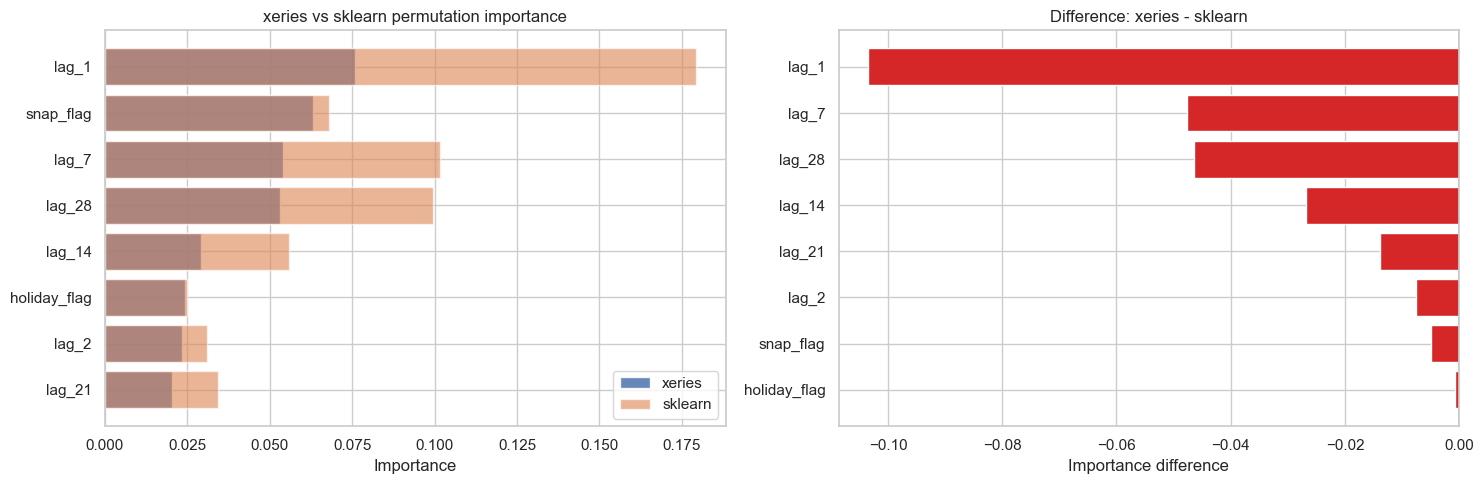

Spearman rank correlation: 0.833


In [9]:
print('Computing sklearn permutation importance...')

sk_model = getattr(forecaster, 'regressor_', forecaster.regressor)
sklearn_pi = permutation_importance(
    sk_model,
    X_train_sk,
    y_train_sk,
    n_repeats=20,
    random_state=42,
    scoring='neg_mean_squared_error',
)

sklearn_importance_df = pd.DataFrame({
    'feature': X_train_sk.columns,
    'sklearn_importance': sklearn_pi.importances_mean,
    'sklearn_std': sklearn_pi.importances_std,
}).sort_values('sklearn_importance', ascending=False)

comparison_df = (
    importance_df.merge(sklearn_importance_df, on='feature', how='inner')
    .assign(importance_diff=lambda df: df['importance'] - df['sklearn_importance'])
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
 )

print('=== xeries vs sklearn permutation importance (top 12 by xeries) ===')
display(comparison_df.head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_compare = comparison_df.head(12).iloc[::-1]
axes[0].barh(top_compare['feature'], top_compare['importance'], label='xeries', alpha=0.85)
axes[0].barh(top_compare['feature'], top_compare['sklearn_importance'], label='sklearn', alpha=0.6)
axes[0].set_title('xeries vs sklearn permutation importance')
axes[0].set_xlabel('Importance')
axes[0].legend()

top_diff = comparison_df.reindex(
    comparison_df['importance_diff'].abs().sort_values(ascending=False).head(12).index
 ).iloc[::-1]
axes[1].barh(top_diff['feature'], top_diff['importance_diff'], color='#d62728')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Difference: xeries - sklearn')
axes[1].set_xlabel('Importance difference')

plt.tight_layout()
plt.show()

rank_corr = comparison_df['importance'].rank().corr(
    comparison_df['sklearn_importance'].rank(),
    method='spearman',
)
print(f'Spearman rank correlation: {rank_corr:.3f}')

## 7. Per-Series Importance and SNAP/Holiday Comparison

Computing per-series importance...


e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

Per-series results computed for 9 series.
Saved per-series importance figures to E:\research\beyond-global-averages\outputs\figures


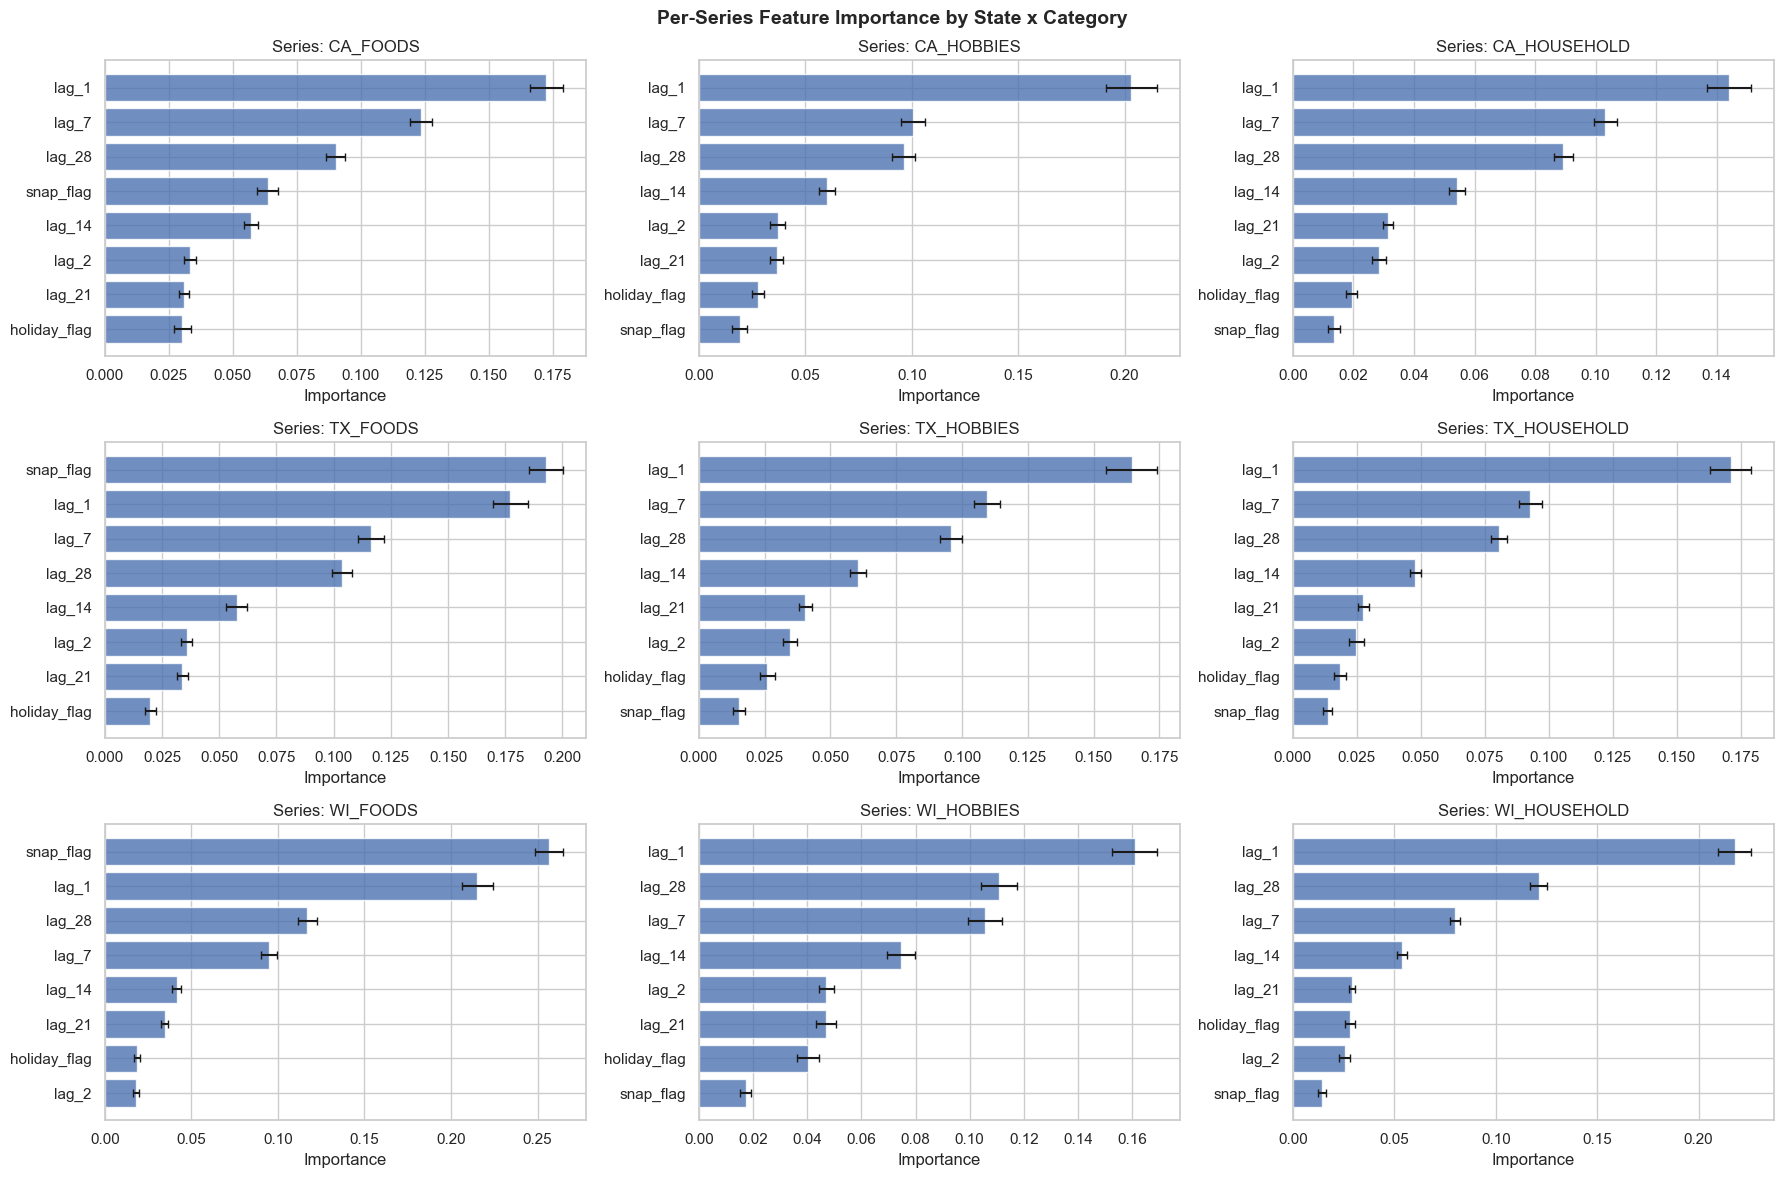

Saved per-series importance tables to E:\research\beyond-global-averages\outputs\tables


In [10]:
print('Computing per-series importance...')
per_series_raw = explainer.explain_per_series(
    X=X_train_sk,
    y=y_train_sk,
    series_col=series_col,
    features=explain_features,
)

# Map ordinal-coded keys back to readable names if needed.
alphabetical_series_ids = sorted(series_ids)
per_series_results = {}
for key, result in per_series_raw.items():
    readable = None
    if key in series_ids:
        readable = key
    else:
        try:
            key_int = int(key)
            if 0 <= key_int < len(alphabetical_series_ids):
                readable = alphabetical_series_ids[key_int]
        except (TypeError, ValueError):
            readable = None

    if readable is None:
        readable = str(key)

    per_series_results[readable] = result

print(f'Per-series results computed for {len(per_series_results)} series.')

fig, axes = plot_importance_per_series(
    per_series_results,
    max_features=10,
    ncols=3,
    title=None,
)
plt.tight_layout()
for idx, ax in enumerate(axes.flatten()[:len(per_series_results)]):
    if idx < len(per_series_results) - 3:
        ax.set_xlabel('')
plt.tight_layout()
fig.savefig(FIGURE_DIR / '02_m5_per_series_importance.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '02_m5_per_series_importance.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved per-series importance figures to {FIGURE_DIR}')
plt.show()

# Export per-series importance table
per_series_df = pd.concat([
    r.to_dataframe().assign(series=name)
    for name, r in per_series_results.items()
])
per_series_df.to_csv(TABLE_DIR / '02_m5_per_series_importance.csv', index=False)

# Export LaTeX table
latex_per_series = per_series_df.to_latex(index=False, float_format='%.4f',
    caption='M5 per-series feature importance scores.',
    label='tab:02_m5_per_series_importance')
with open(TABLE_DIR / '02_m5_per_series_importance.tex', 'w') as f:
    f.write(latex_per_series)
print(f'Saved per-series importance tables to {TABLE_DIR}')

Per-series exogenous importance table:


,state_id,cat_id,series,feature,importance
12,WI,FOODS,WI_FOODS,snap_flag,0.256595
6,TX,FOODS,TX_FOODS,snap_flag,0.192900
0,CA,FOODS,CA_FOODS,snap_flag,0.063689
14,WI,HOBBIES,WI_HOBBIES,holiday_flag,0.040375
1,CA,FOODS,CA_FOODS,holiday_flag,0.030255
16,WI,HOUSEHOLD,WI_HOUSEHOLD,holiday_flag,0.028313
2,CA,HOBBIES,CA_HOBBIES,holiday_flag,0.027820
8,TX,HOBBIES,TX_HOBBIES,holiday_flag,0.025955
7,TX,FOODS,TX_FOODS,holiday_flag,0.019901
4,CA,HOUSEHOLD,CA_HOUSEHOLD,holiday_flag,0.019377


Saved SNAP/Holiday heatmaps to E:\research\beyond-global-averages\outputs\figures


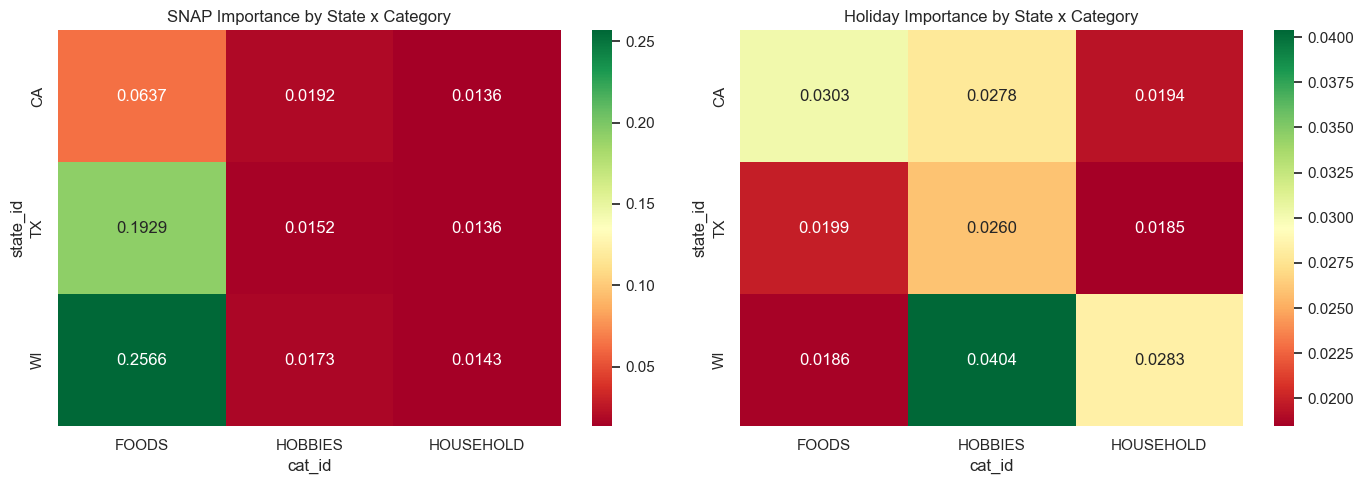

Saved SNAP importance heatmap to E:\research\beyond-global-averages\outputs\figures


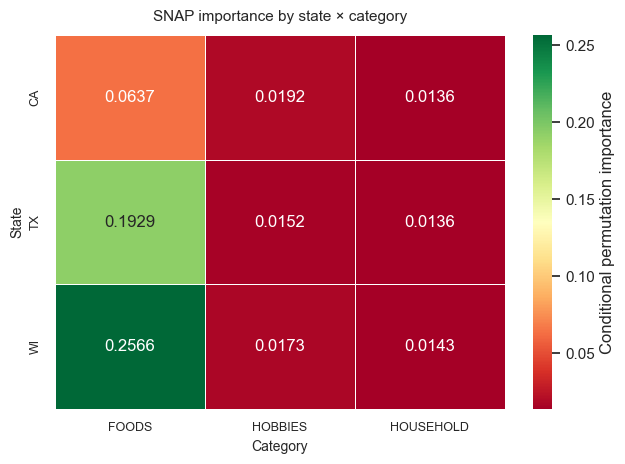

In [11]:
rows = []
for series_name, result in per_series_results.items():
    state_id, cat_id = series_name.split('_', 1)
    df = result.to_dataframe()

    for _, row in df.iterrows():
        feature = row['feature']
        if feature in exog_features:
            rows.append({
                'state_id': state_id,
                'cat_id': cat_id,
                'series': series_name,
                'feature': feature,
                'importance': float(row['importance']),
            })

exog_comp = pd.DataFrame(rows)
print('Per-series exogenous importance table:')
display(exog_comp.sort_values('importance', ascending=False))

snap_matrix = exog_comp[exog_comp['feature'] == 'snap_flag'].pivot(
    index='state_id',
    columns='cat_id',
    values='importance',
)
holiday_matrix = exog_comp[exog_comp['feature'] == 'holiday_flag'].pivot(
    index='state_id',
    columns='cat_id',
    values='importance',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(snap_matrix, annot=True, fmt='.4f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('SNAP Importance by State $\\times$ Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('State')

sns.heatmap(holiday_matrix, annot=True, fmt='.4f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Holiday Importance by State $\\times$ Category')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('State')

plt.tight_layout()
fig.savefig(FIGURE_DIR / '02_m5_snap_holiday_heatmaps.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '02_m5_snap_holiday_heatmaps.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved SNAP/Holiday heatmaps to {FIGURE_DIR}')
plt.show()

#  SNAP heatmap (state x category) and export to PDF.
fig, ax = plt.subplots(figsize=(6.5, 4.8))

sns.heatmap(
    snap_matrix,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Conditional permutation importance"},
    ax=ax,
)

ax.set_title("SNAP importance by state × category", fontsize=11, pad=10)
ax.set_xlabel("Category", fontsize=10)
ax.set_ylabel("State", fontsize=10)
ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
fig.savefig(FIGURE_DIR / '02_m5_snap_importance_state_category.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '02_m5_snap_importance_state_category.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved SNAP importance heatmap to {FIGURE_DIR}')
plt.show()


SNAP importance by state:
state_id
WI    0.096066
TX    0.073898
CA    0.032148
Name: importance, dtype: float64

SNAP importance by category:
cat_id
FOODS        0.171061
HOBBIES      0.017222
HOUSEHOLD    0.013829
Name: importance, dtype: float64
Saved SNAP summary bar charts to E:\research\beyond-global-averages\outputs\figures


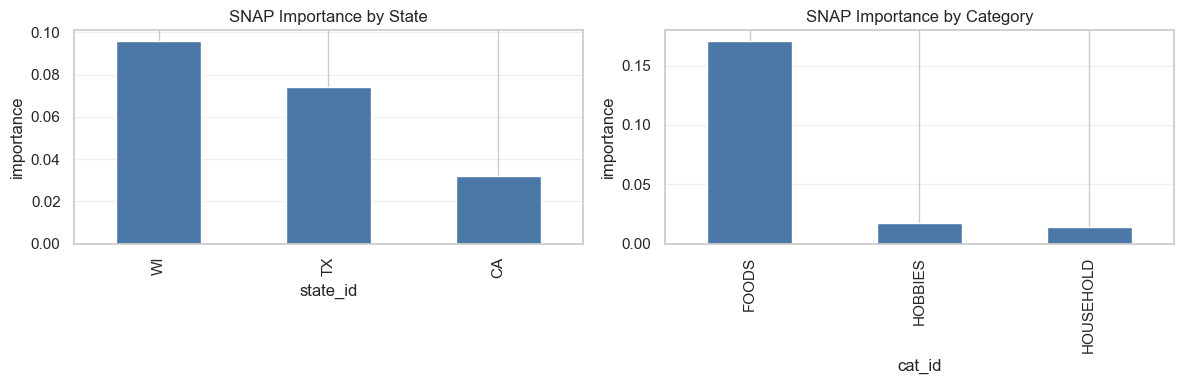

In [12]:
snap_by_state = (
    exog_comp[exog_comp['feature'] == 'snap_flag']
    .groupby('state_id')['importance']
    .mean()
    .sort_values(ascending=False)
)
snap_by_category = (
    exog_comp[exog_comp['feature'] == 'snap_flag']
    .groupby('cat_id')['importance']
    .mean()
    .sort_values(ascending=False)
)

print('SNAP importance by state:')
print(snap_by_state)
print('\nSNAP importance by category:')
print(snap_by_category)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
snap_by_state.plot(kind='bar', color='#4c78a8', ax=axes[0], title='SNAP Importance by State')
axes[0].set_ylabel('importance')
axes[0].grid(axis='y', alpha=0.3)

snap_by_category.plot(kind='bar', color='#4c78a8', ax=axes[1], title='SNAP Importance by Category')
axes[1].set_ylabel('importance')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURE_DIR / '02_m5_snap_summary_bars.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '02_m5_snap_summary_bars.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved SNAP summary bar charts to {FIGURE_DIR}')
plt.show()

## 8. Summary

This notebook provides the same workflow pattern as notebook 02 on M5 aggregated series:
- Global feature importance
- Per-series feature importance
- SNAP/holiday heterogeneity across state x category